# **Week4 (Classification) 과제**

# Red Wine Quality Classification

## 데이터 소개
  
UCI Machine Learning  
**TASK : Red wine Classification**  
https://archive.ics.uci.edu/dataset/186/wine+quality


csv 파일의 컬럼은 아래와 같습니다.

*   index : 구분자
*   quality : 품질
*   fixed acidity : 산도
*   volatile acidity : 휘발성산
*   citric acid : 시트르산
*   residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
*   chlorides : 염화물
*   free sulfur dioxide : 독립 이산화황
*   total sulfur dioxide : 총 이산화황
*   density : 밀도
*   pH : 수소이온농도
*   sulphates : 황산염
*   alcohol : 도수
*   type : 종류



In [ ]:
# 코랩 환경: 구글 드라이브에 코랩을 연동
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# necessary imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [39]:
# loading data ,your own file path
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## EDA(Exploratory Data Analysis)

In [24]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Q1 Data brief review : info() 함수를 통해 알아낼 수 있는 정보를 작성하시오. 
(**빈칸 ## 4개를 채우시오**)


답: It turns out that the dataset does not have (**missing**) values. The dataset consists of (**1599**) rows and (**12**) columns. The data type of all variables are (float64).



In [25]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [26]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Q2 결측치 확인
결측치가 존재한다면, 이를 처리하는 방법에 대해 알아보고 정리해주세요.

결측치는 판단에 따라 drop(제거) 할 수 있고, 특정 값으로 채울(대체) 수 있습니다.

데이터를 채우는 방법으로는 수치형 데이터는 통계를 이용해서, 범주형 데이터는 unique(), value_counts() 등으로 처리합니다.

In [ ]:
# 결측치 확인
## df의 결측치의 총 합을 확인하는 코드를 작성하며, ##을 채우세요. sum()을 2번 사용하시오.

print("There are {} null values in the dataset".format(df.isnull().sum().sum()))

# 결측치는 존재하지 않는다

There are 0 null values in the dataset


### Q3 데이터 분포 확인
각 변수의 데이터 분포가 어떠한지 기술하시오.(맨 위의 세개의 변수에 대해서만 기술)

1. 'fixed_acidity' : slightly right skewed, outlier may exist
2. 'volatile_acidity' : show similar distribution as 'fixed_acidity'
3. 'citric_acid' : non-symmetric, highly distribited on 0 value

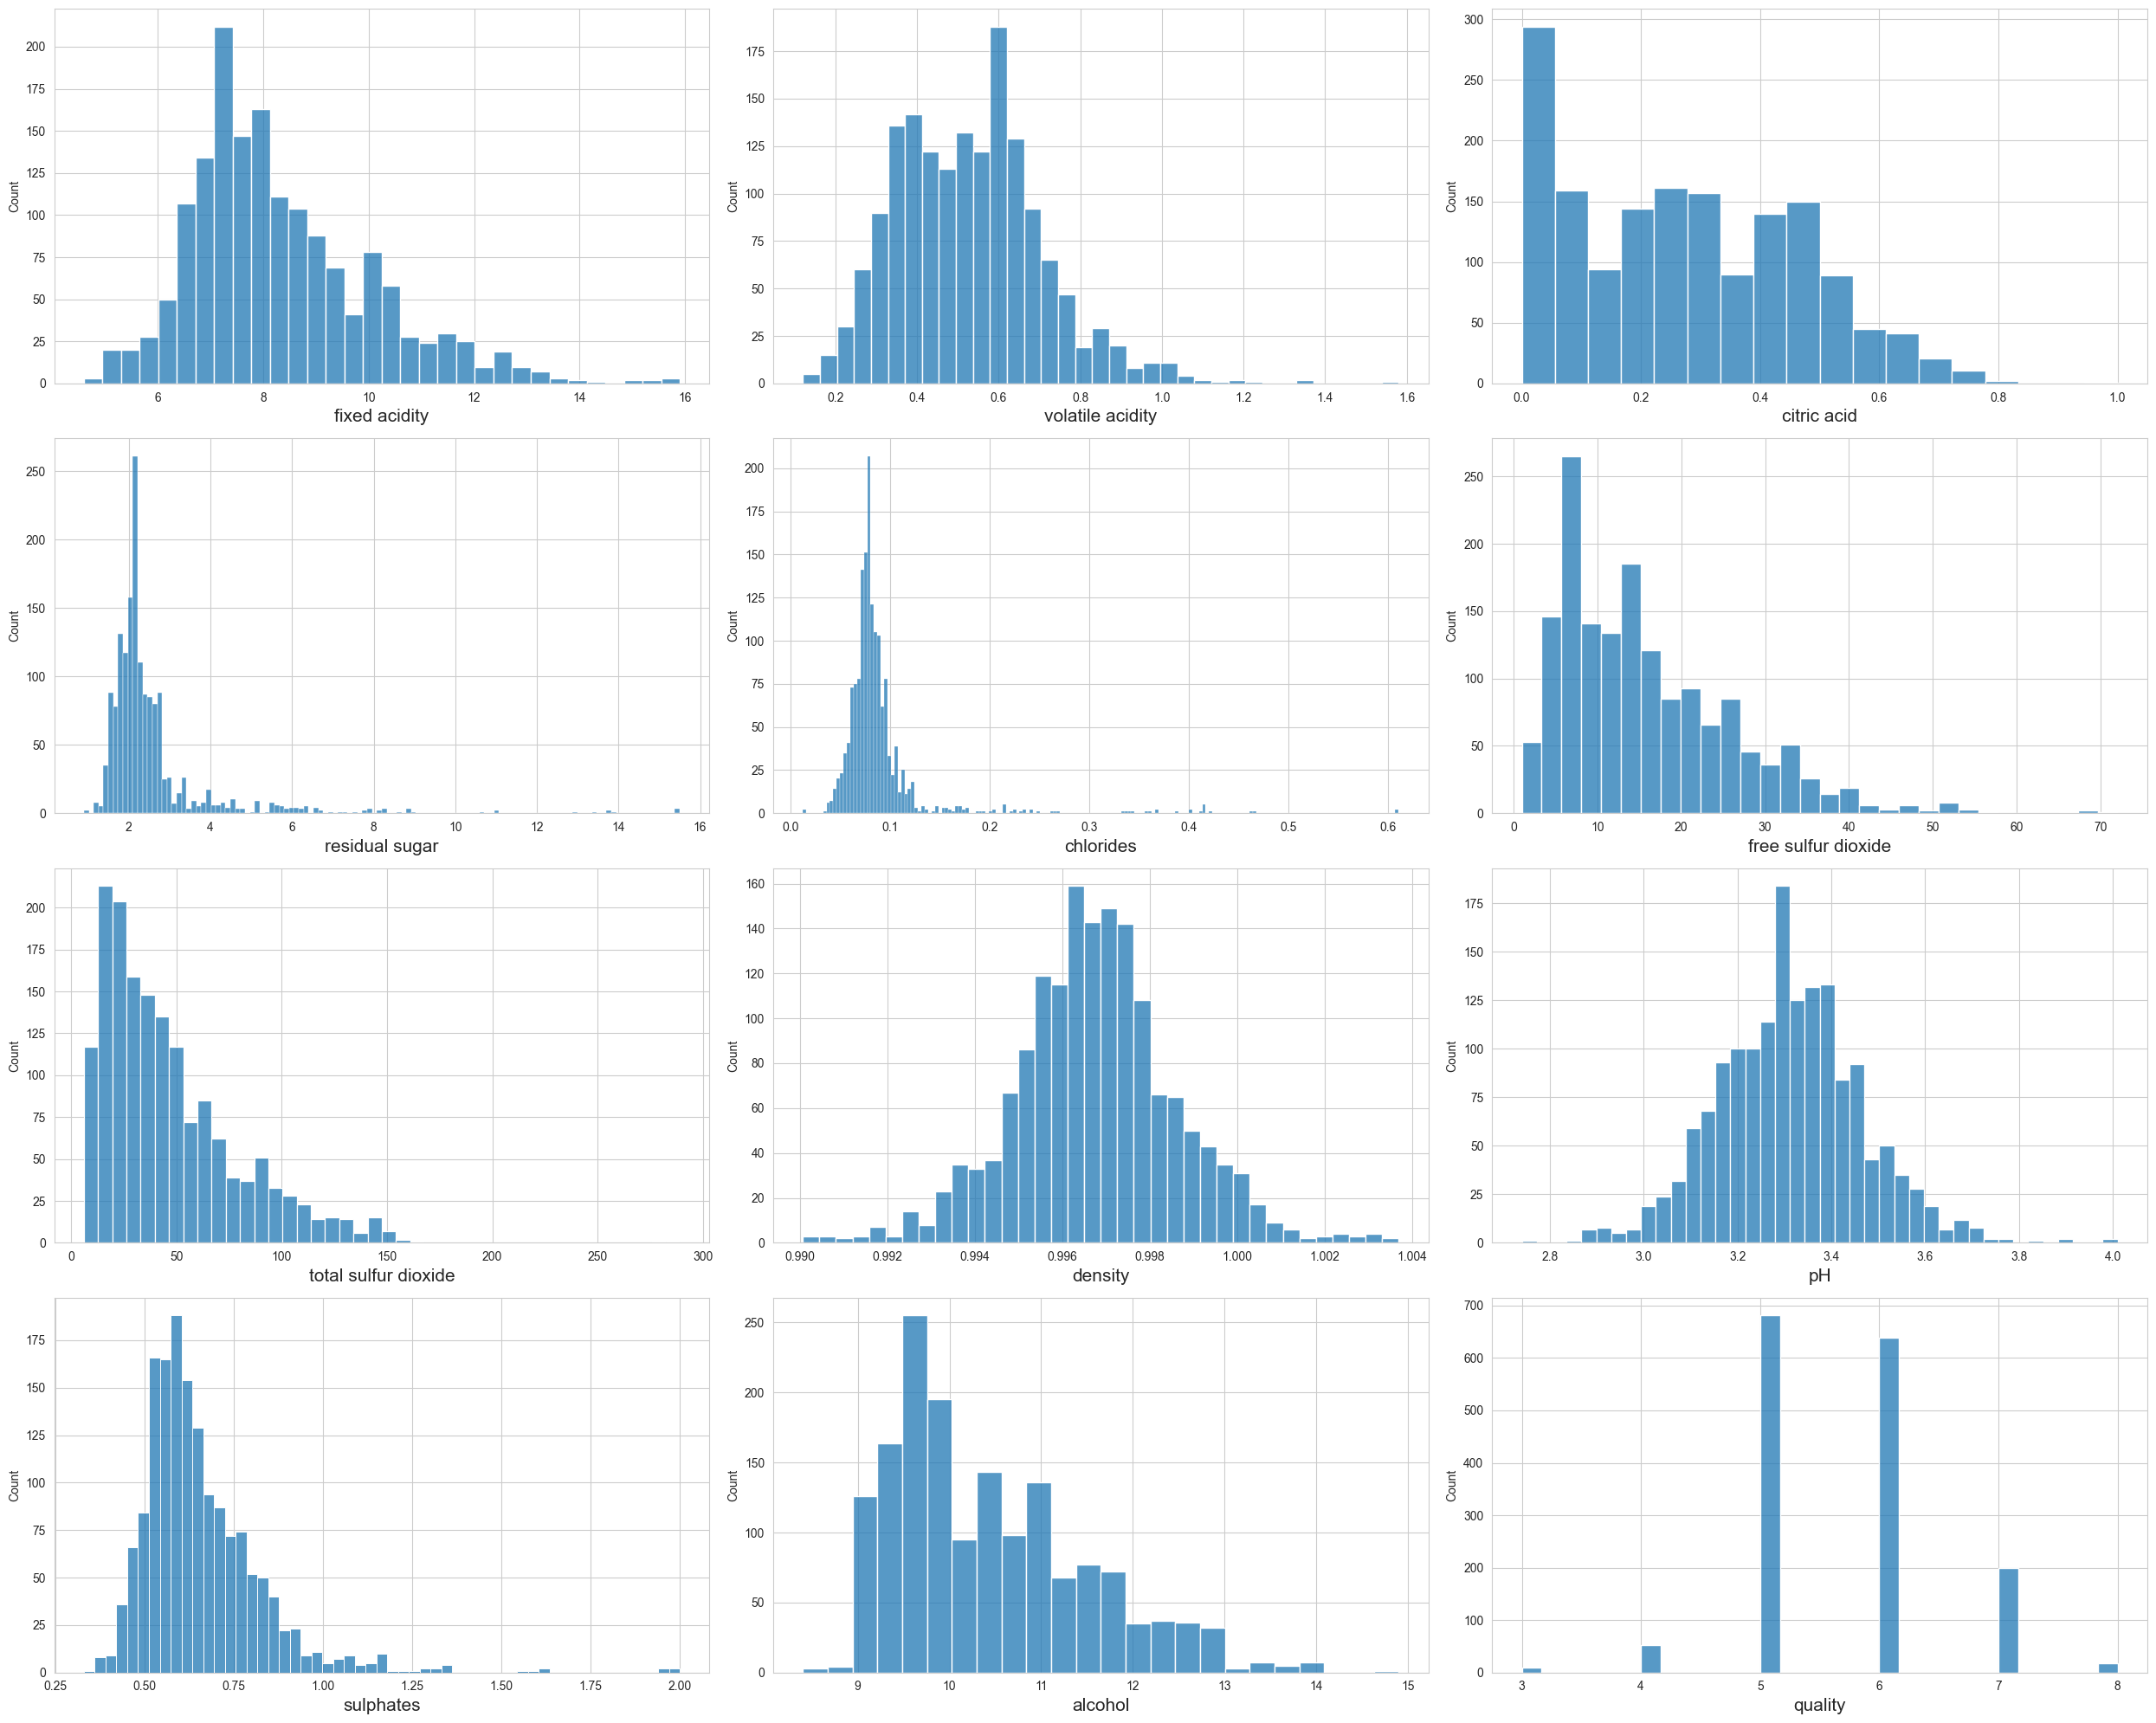

In [15]:
# let's see how data is distributed for every column
plt.figure(figsize = (25, 20))
plotnumber = 1

for col in df:
    if plotnumber <= 12:
        ax = plt.subplot(4, 3, plotnumber)
        sns.histplot(df[col])
        plt.xlabel(col, fontsize = 15)

    plotnumber += 1

plt.tight_layout()
plt.show()

### Q4. correlation plot을 그리고, 해당 plot에서 얻은 인사이트를 정리해보세요.

더불어 multicollinearity(통계학의 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제)에 주목하여, 해당 correlation plot에서 어떤 영향을 주고 있는지 있는지 예를 들어 기술하시오.

답: 여러 변수가 다중공선성의 소지를 가진다. correlation plot에서 일부 예를 들자면, alchol과 density, fixed acidyty와 pH, critic acid와 pH는 -0.5~-0.6의 상관계수를 가지며 강한 음의 상관관계를 보인다. 
또한 free sulfur dioxide와 total sulfur dioxide, fixed acidity와 density는 강한 양의 상관관계(0.66)을 보여 데이터 분석에 왜곡을 일으킬 수 있다. 



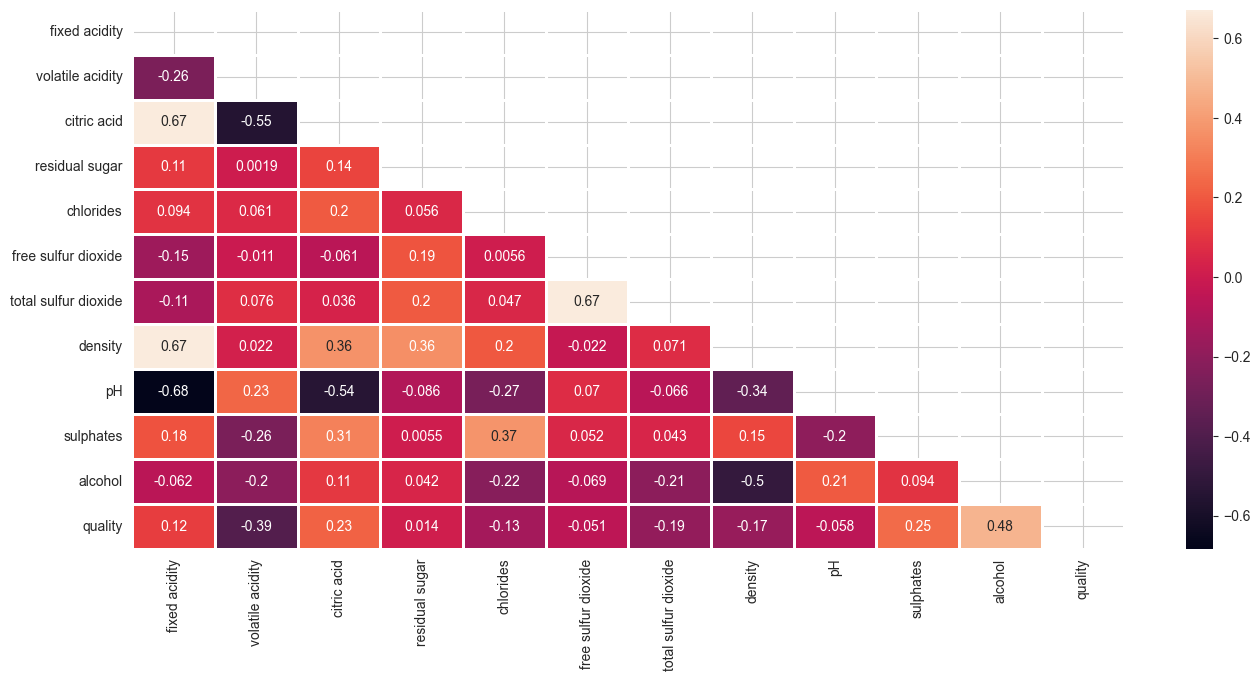

In [29]:
# 상관관계 plot
plt.figure(figsize = (16, 7))

corr = df.corr() # 각 변수들 간 상관계수 계산

mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, annot = True, fmt = '0.2g', linewidths = 1)
plt.show()

In [28]:
#Pearson correlation coefficient
import scipy.stats as st
print("Pearson correlation coefficient:", st.pearsonr(df["alcohol"],df["density"]))
print("Pearson correlation coefficient:", st.pearsonr(df["free sulfur dioxide"],df["total sulfur dioxide"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["citric acid"],df["pH"]))
print("Pearson correlation coefficient:", st.pearsonr(df["fixed acidity"],df["density"]))

Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.4961797702417016), pvalue=np.float64(3.9388353399881185e-100))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6676664504810215), pvalue=np.float64(6.40472295468261e-207))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.6829781945685315), pvalue=np.float64(4.063034039843853e-220))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(-0.5419041447395098), pvalue=np.float64(1.0072013259111632e-122))
Pearson correlation coefficient: PearsonRResult(statistic=np.float64(0.6680472921189734), pvalue=np.float64(3.0747470608608655e-207))


### Q5. quality range를 두 파트로 나눠보세요.
In this dataset quality range is between 3 and 8
We will divide quality range into two parts:



*   High quality wine: 6 - 8
*   Low quality wine: 3 - 5



In [ ]:
df["quality"] = df["quality"].apply(lambda x: "High" if x >= 6 else "Low")
df["quality"]

# lamda : 파이썬에서 한줄짜리 함수 만들때 쓰는 문법
# lamda 매개변수 : 반환값, 간단한 함수 정의

0        Low
1        Low
2        Low
3       High
4        Low
        ... 
1594     Low
1595    High
1596    High
1597     Low
1598    High
Name: quality, Length: 1599, dtype: object

In [42]:
pip install jinja2

   ---------------------------------------- 0.0/134.9 kB ? eta -:--:--
   ------------ --------------------------- 41.0/134.9 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 134.9/134.9 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
df.head().style.background_gradient(cmap = "Reds")

# 데이터프레임 시각화, 값의 크기가 클수록 빨강색으로 표현 (동일 variable 기준)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,Low
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,Low
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,Low
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,High
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,Low


### Q6. 종속변수(y,label)은 무엇이 되어야 하나요?


In [44]:
# we select dependent variable (label)
y = df["quality"] 

# we select independent variable
x = df.drop("quality", axis = 1)

In [45]:
# splitting data into training and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    shuffle = True,
                                                    random_state = 1)

### Q7. 왜 Standardization(StandardScaler, MinMaxScaler 등) 사용할까요? 
두 Scaler의 특징에 대해 조사하고, 보다 적절한 Scaler가 무엇일지 그 이유와 함께 적어주세요.

답 : Min Max scaler

standard scaler는 데이터의 평균을 뺀 값을 표준편차로 나누어 (x - x_min / x_ss) scaling, 전체적 분포는 유지하며 중심과 스케일만 다른 변수와 비슷한 범위로 조정한다. 
minmax sclaer는 (x - x_min) / (x_max - x_min)으로 데이터를 0~1로 변환한다. 

우리가 할 분석 방법은 KNN, 즉 거리 기반 알고리즘이기 때문에 모든 데이터를 0~1로 조정하는 Min Max scaler가 더 적합하다. 

In [47]:
# scaling data
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler(feature_range = (0, 1))
norm.fit(x_train)
x_train = norm.transform(x_train)
x_test = norm.transform(x_test)

### Q7-2. 위의 코드에서, train dataset에 대해서는 fit_transform을, test dataset에 대해서는 transform을 실시하는 이유가 무엇일지 조사해주세요.
답 : test dataset에 fit_transform을 적용할 경우 Data leakage 가 발생한다. 

fit_transform (= fit() + transform()) 은 데이터의 기준값(평균, 최소, 최대 등)을 학습한 뒤, 이를 기준으로 데이터를 변환하는 과정이다. 
만약 test dataset에도 fit()을 적용할 경우, 모델이 train기준만 아는 것이 아니라 test 기준도 학습해버리기 때문에 새로운 기준값이 생겨버리고, data leakage가 발생한다. 

In [48]:
print(x_train[0:5])
print("\n")
print(x_train.shape)
print("_________________________________________________________________________")
print(x_test[0:5])
print("\n")
print(x_test.shape)

[[0.23893805 0.1369863  0.23       0.10769231 0.090301   0.47887324
  0.23529412 0.4441896  0.54330709 0.17365269 0.26153846]
 [0.32743363 0.38013699 0.26       0.09230769 0.12040134 0.14084507
  0.13602941 0.57568807 0.4488189  0.11976048 0.12307692]
 [0.69911504 0.17808219 0.6        0.13076923 0.11538462 0.42253521
  0.24264706 0.72859327 0.28346457 0.23952096 0.32307692]
 [0.36283186 0.44178082 0.22       0.10769231 0.08695652 0.11267606
  0.13235294 0.47629969 0.28346457 0.13173653 0.15384615]
 [0.32743363 0.49657534 0.01       0.1        0.09698997 0.05633803
  0.02941176 0.50688073 0.45669291 0.1497006  0.4       ]]


(1199, 11)
_________________________________________________________________________
[[0.37168142 0.19863014 0.64       0.1        0.13545151 0.11267606
  0.13235294 0.65214067 0.62992126 0.19760479 0.32307692]
 [0.36283186 0.34931507 0.28       0.13846154 0.14046823 0.22535211
  0.23161765 0.5558104  0.40944882 0.17964072 0.27692308]
 [0.51327434 0.15068493 0.58  

In [49]:
print(y_train.head())
print(y_train.shape)
print("___________________________")
print(y_test.head())
print(y_test.shape)

1144    Low
73      Low
446     Low
399     Low
647     Low
Name: quality, dtype: object
(1199,)
___________________________
75       Low
1283    High
408     High
1281    High
1118    High
Name: quality, dtype: object
(400,)


### Q8. Building Classification models

이번 코드에서는 non parametric model; knn을 사용하여 train, test 진행해보았습니다.

아래의 코드 외에도 원하는 한가지 classification 모델(KNN 제외)을 선정하여 아래의 과정을 반복하고, 그 결과를 해석하세요. grid search 과정은 거치지 않고 임의의 파라미터값으로 진행해도 좋습니다.

아래와 같은 Kaggle 코드들도 참고해보세요.  
- https://www.kaggle.com/code/melissamonfared/red-wine-quality-prediction-eda-classification/notebook
- https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification


Accuracy: 0.715

Confusion Matrix:
 [[156  58]
 [ 56 130]]

Classification Report:
               precision    recall  f1-score   support

        High       0.74      0.73      0.73       214
         Low       0.69      0.70      0.70       186

    accuracy                           0.71       400
   macro avg       0.71      0.71      0.71       400
weighted avg       0.72      0.71      0.72       400

For Logistic Regression

Training Accuracy: 75.4796 %

Testing Accuracy: 71.5000 %

Accuracy Score: 71.5000 %



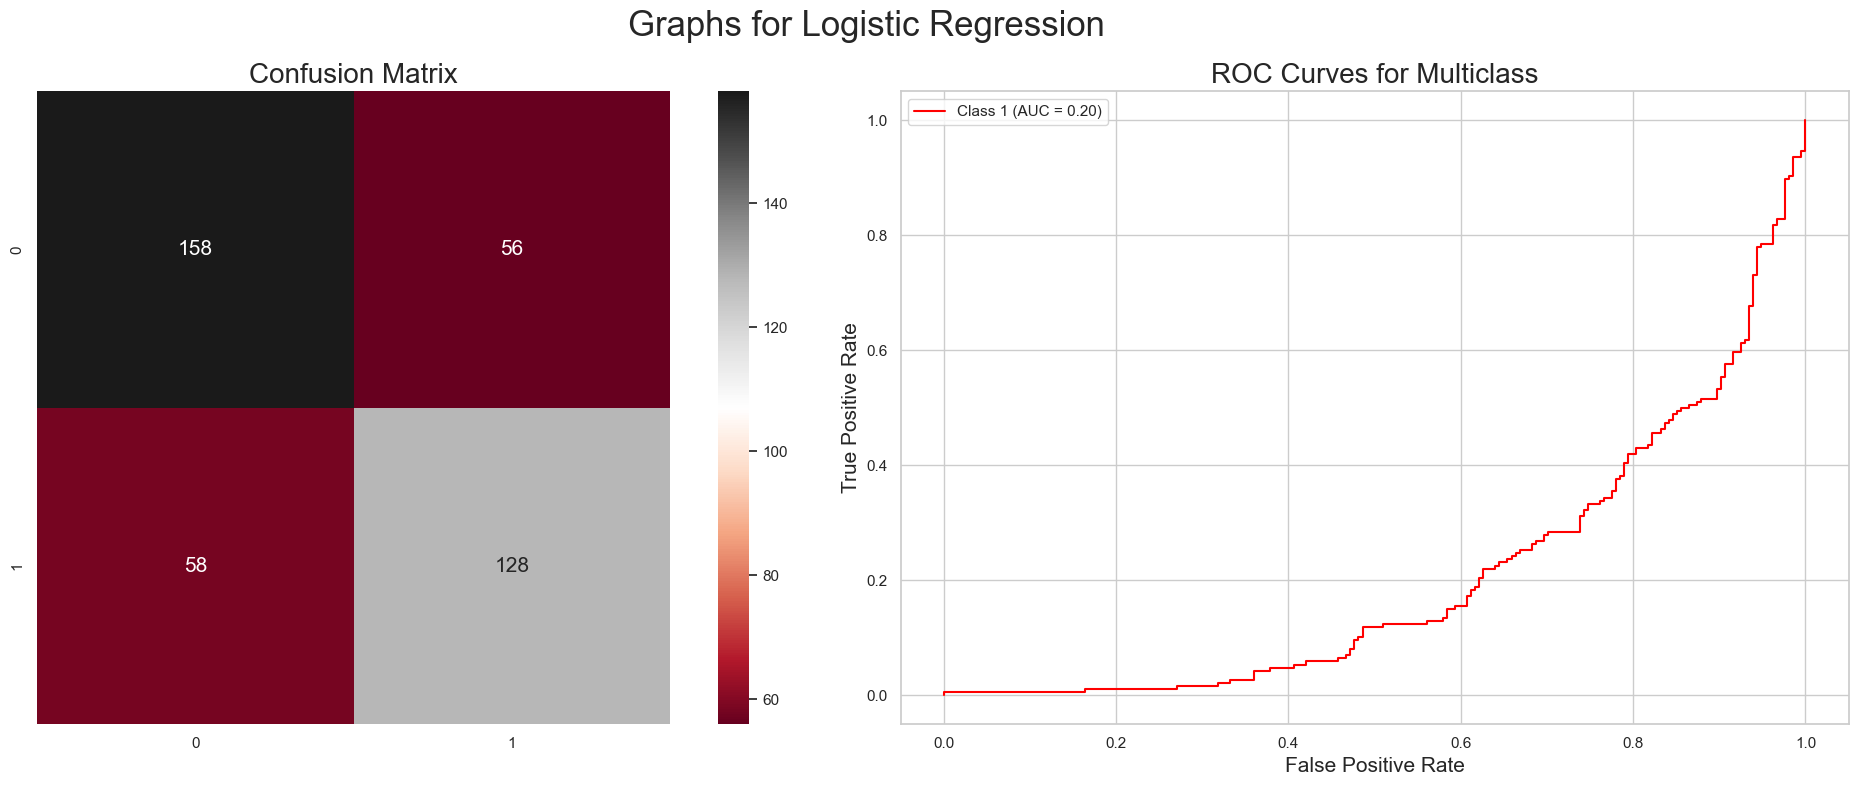

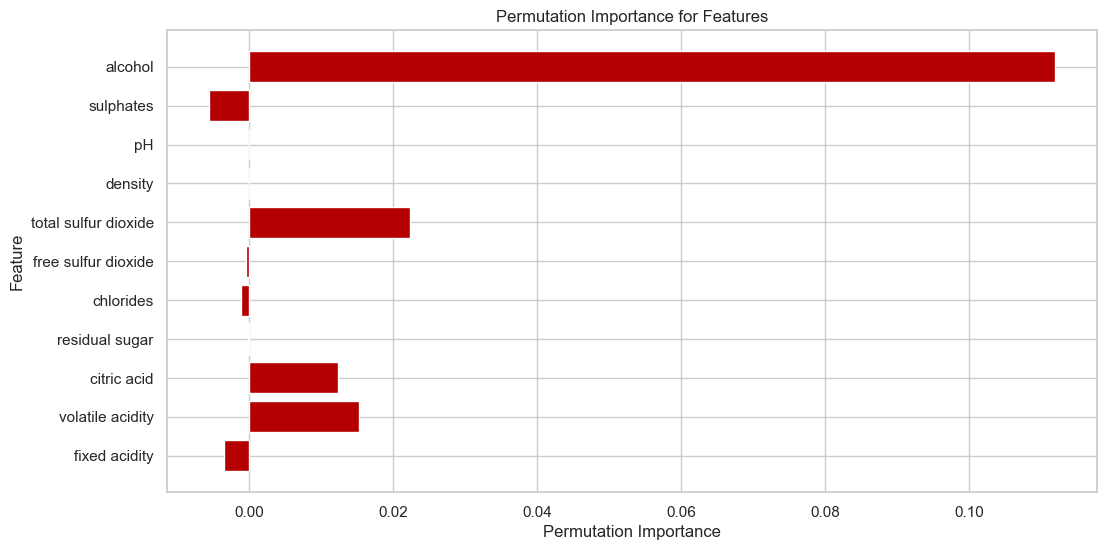

In [ ]:
## Logistic regression으로 분류

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

x = df.drop("quality", axis = 1)
y = df["quality"] 

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size = 0.25,
                                                    stratify=y,
                                                    random_state = 1)
# startify = y <- 데이터의 클래스(High, Low)비율을 동일하게 유지


log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, C=1.0, solver='lbfgs')
)
# make_piplene : 여러 단계를 하나의 모델로 묶어줌
# max_iter : 모델이 최적해를 찾기 위해 반복하는 최대 횟수
# C=1.0 : regularization의 강도 조절, 과적합 방지용 하이퍼파라미터
# solver=lbfgs : 최적화 알고리즘 선택, small dataset에 적합, 빠르고 안정적이라는 특징 가진다. 

log_model.fit(x_train, y_train)

y_pred = log_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

evaluate_model('Logistic Regression',
                           LogisticRegression(C=1.0, fit_intercept=True, 
                                              max_iter=5000, solver='lbfgs'))

# logistic regression의 accuracy : 0.715
# KNN의 accuracy : 0.805
# KNN 알고리즘이 logistic regression보다 분류 성능이 우수하다.


In [ ]:
# https://www.kaggle.com/code/melissamonfared/red-wine-quality-prediction-eda-classification?scriptVersionId=206524330&cellId=42
# 참고해서 evaluate_model 평가 함수 제작, 그래픽화

# Initialize lists to store algorithm names, accuracies, and model details

import os

import re

import string

import random

import sklearn

import numpy as np

import pandas as pd

import seaborn as sns

from PIL import Image

from tqdm import tqdm

import lightgbm as lgbm

import missingno as msno

from sklearn.svm import SVC

import plotly.express as px

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.utils import shuffle

from catboost import CatBoostClassifier

from matplotlib.ticker import FuncFormatter

from sklearn.metrics import RocCurveDisplay

from sklearn.ensemble import AdaBoostClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import LabelBinarizer

from sklearn.linear_model import LogisticRegression

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import confusion_matrix, roc_curve, RocCurveDisplay, auc, accuracy_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier

import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

sns.set(color_codes = True)   

sns.set_palette(palette = 'gist_heat', n_colors = 8)

sns.set(style="whitegrid")
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix, roc_curve, RocCurveDisplay, auc, accuracy_score
from sklearn.inspection import permutation_importance

al = []
accuracy = []
models = []

# Function to evaluate the performance of a model

def evaluate_model(algorithm_name, model): 
    # Train the model and make predictions
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_pred_prob = model.predict_proba(x_test)

    # Calculate accuracy scores
    acc_model = model.score(x_test, y_test)
    train_acc_model = model.score(x_train, y_train)

    # Store the algorithm name and accuracy
    al.append(algorithm_name)
    accuracy.append(acc_model)

    # Print performance metrics

    print('\033[31m' + f'For {algorithm_name}' + '\033[0m\n')  # Red color for algorithm name
    print(f'Training Accuracy: {train_acc_model * 100:.4f} %\n')

    print(f'Testing Accuracy: {acc_model * 100:.4f} %\n')

    print(f'Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.4f} %\n')

    # Create subplots for the confusion matrix and ROC curve

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    plt.subplot(1, 2, 1)

    fig.suptitle(f'Graphs for {algorithm_name}', fontsize=25)



    # Plot the confusion matrix

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, 

                cmap='RdGy', annot_kws={'size': 15}, 

                square=True, fmt='.0f',

                ax=axes[0])

    axes[0].set_title('Confusion Matrix', fontsize=20)

    

    # Plot the ROC curve for multiclass using one-vs-rest strategy

    plt.subplot(1, 2, 2)

    lb = LabelBinarizer()

    y_test_bin = lb.fit_transform(y_test)  # Binarize the test labels for multiclass ROC

    

    for i in range(y_test_bin.shape[1]):  # loop through each class

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])

        roc = auc(fpr, tpr)

        axes[1].plot(fpr, tpr, label=f'Class {i+1} (AUC = {roc:.2f})', color='red')

    

    axes[1].set_xlabel('False Positive Rate', fontsize=15)

    axes[1].set_ylabel('True Positive Rate', fontsize=15)

    axes[1].set_title(f'ROC Curves for Multiclass', fontsize=20)

    axes[1].legend()

    

    plt.tight_layout()

    plt.show()



    # Plot permutation importance for feature evaluation

    if algorithm_name != 'K Nearest Neighbors':

        # Calculate permutation importance

        perm_importance = permutation_importance(model, x_test, y_test, n_repeats=30, random_state=42)



        # Extract and plot feature importances

        feature_importance = perm_importance.importances_mean
        train_columns = x_train.columns

        feature_names = train_columns



        plt.figure(figsize=(12, 6))

        plt.barh(feature_names, feature_importance, color='#b40000')  # Red color for bars

        plt.xlabel('Permutation Importance')

        plt.ylabel('Feature')

        plt.title('Permutation Importance for Features')

        plt.show()

    

    # Extract confusion matrix values (True Positive, False Positive, etc.)

    tp = confusion_matrix(y_test, y_pred)[0, 0]

    fp = confusion_matrix(y_test, y_pred)[0, 1]

    tn = confusion_matrix(y_test, y_pred)[1, 1]

    fn = confusion_matrix(y_test, y_pred)[1, 0]



    # Append the model evaluation results to the models list

    models.append((algorithm_name, tp, fp, tn, fn, train_acc_model, acc_model))



In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
#KNN

knn = KNeighborsClassifier()

knn_params = {"n_neighbors": np.arange(2, 50),
             "weights": ["uniform", "distance"],
             "leaf_size": [25, 30, 25]}

knn_cv_model = GridSearchCV(knn, knn_params, cv = 10)
knn_cv_model.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'leaf_size': [25, 30, ...], 'n_neighbors': array([ 2, 3..., 47, 48, 49]), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [ ]:
print("Best score for train set: " + str(knn_cv_model.best_score_))

print("____________________________________________")

print("best K value: " + str(knn_cv_model.best_params_["n_neighbors"]),
     "\nbest weights: " + knn_cv_model.best_params_["weights"],
     "\nbest leaf size: " + str(knn_cv_model.best_params_["leaf_size"]))

Best score for train set: 0.798172268907563
____________________________________________
best K value: 21 
best weights: distance 
best leaf size: 25


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = knn_cv_model.best_params_["n_neighbors"],
                                leaf_size = knn_cv_model.best_params_["leaf_size"],
                                weights = knn_cv_model.best_params_["weights"])

knn_model.fit(x_train, y_train)

KNeighborsClassifier(leaf_size=25, n_neighbors=21, weights='distance')

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = knn_model.predict(x_test)
print("Accuracy:",accuracy_score(y_test, y_pred)) #Validation Set Accurac

Accuracy: 0.8025


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.81      0.79       188
           1       0.82      0.80      0.81       212

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



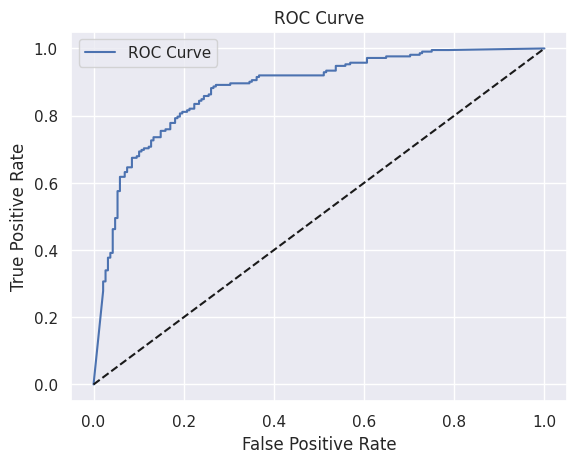

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
# Validation Set 에 대한 예측확률 계산
y_prob = knn_model.predict_proba(x_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = "ROC Curve")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()